# Novel segmentation algorithms

In addition to the standard cellpose version that is integrated in Steinbock, we want to provide newer models for segmentation in the future, namely InstanSeg and CellposeSAM. Up to this point, these models are not yet implemented in Steinbock, therefore we provide it here as standalone script.

In [1]:
import numpy as np
import os
import pandas as pd
import tifffile

from cellpose import models, core, io, plot
from instanseg import InstanSeg
from instanseg.utils.utils import show_images

## Create segmentation stack (as in steinbock)

In [2]:
def create_segmentation_stack(
    img: np.ndarray,
    channelwise_minmax: bool = False,
    channelwise_zscore: bool = False,
    channel_groups = None,
    aggr_func = np.mean,
) -> np.ndarray:
    if channelwise_minmax:
        channel_mins = np.nanmin(img, axis=(1, 2))
        channel_maxs = np.nanmax(img, axis=(1, 2))
        channel_ranges = channel_maxs - channel_mins
        img -= channel_mins[:, np.newaxis, np.newaxis]
        img[channel_ranges > 0] /= channel_ranges[
            channel_ranges > 0, np.newaxis, np.newaxis
        ]
    if channelwise_zscore:
        channel_means = np.nanmean(img, axis=(1, 2))
        channel_stds = np.nanstd(img, axis=(1, 2))
        img -= channel_means[:, np.newaxis, np.newaxis]
        img[channel_stds > 0] /= channel_stds[channel_stds > 0, np.newaxis, np.newaxis]
    if channel_groups is not None:
        img = np.stack(
            [
                aggr_func(img[channel_groups == channel_group], axis=0)
                for channel_group in np.unique(channel_groups)
                if not np.isnan(channel_group)
            ]
        )
    return img

## Define InstanSeg and Cellpose SAM mask extraction functions

In [3]:
def segment_instanseg_mask(segmentation_stack, pixel_size = 1):
    labeled_output_small, image_tensor  = instanseg_fluorescence.eval_small_image(segmentation_stack, pixel_size, 
                                                                            resolve_cell_and_nucleus=True, 
                                                                            cleanup_fragments = True,
                                                                            target= "cells")
    return labeled_output_small.squeeze().numpy().astype(np.uint16)  # Remove any singleton dimensions

In [4]:
def segment_cellpose_sam_mask(segmentation_stack):
    flow_threshold = 0.6
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0
    mask_cellpose, flows, styles = model.eval(segmentation_stack, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
    return mask_cellpose

## load images and panel file

In [5]:
img_folder = "../data/cell_mode/img_dimr"
img_files = [i for i in os.listdir(img_folder) if i.endswith(".tiff")]
panel_file_path = "../data/cell_mode/panel.csv"
panel = pd.read_csv(panel_file_path)
panel.head()
img = tifffile.imread(os.path.join(img_folder, img_files[0]))
img.shape

(40, 600, 600)

In [6]:
channel_groups = None
if "cellpose" in panel and panel["cellpose"].notna().any():
    channel_groups = panel["cellpose"].values
channel_groups

array([nan,  1., nan, nan, nan, nan, nan, nan, nan,  2., nan,  2., nan,
       nan,  2., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        2., nan, nan, nan, nan, nan, nan, nan,  2., nan, nan, nan,  1.,
        1.])

## Create InstanSeg segmentation masks

In [7]:
output_folder = "../data/cell_mode/masks_instanseg"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
instanseg_fluorescence = InstanSeg("fluorescence_nuclei_and_cells", verbosity=1)
for n, img_file in enumerate(img_files):
    img = tifffile.imread(os.path.join(img_folder, img_file))
    segmentation_stack = create_segmentation_stack(img, channel_groups=channel_groups, channelwise_minmax=True).transpose(1, 2, 0)
    mask_instanseg = segment_instanseg_mask(segmentation_stack)
    output_path = os.path.join(output_folder, img_file)
    io.imsave(output_path, mask_instanseg)
    print(f"processed image nb. {n}, {img_file}")

Model fluorescence_nuclei_and_cells version 0.1.1 downloaded and extracted to /opt/micromamba/envs/segmentation/lib/python3.11/site-packages/instanseg/utils/../bioimageio_models/
Requesting default device: cpu


/opt/micromamba/envs/segmentation/lib/python3.11/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/opt/micromamba/envs/segmentation/lib/python3.11/site-packages/torch/nn/modules/module.py:1787: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  return forward_call(*args, **kwargs)


processed image nb. 0, Patient1_002.tiff
processed image nb. 1, Patient1_003.tiff
processed image nb. 2, Patient2_001.tiff
processed image nb. 3, Patient3_001.tiff
processed image nb. 4, Patient4_006.tiff
processed image nb. 5, Patient4_007.tiff
processed image nb. 6, Patient4_008.tiff
processed image nb. 7, Patient3_003.tiff
processed image nb. 8, Patient2_003.tiff
processed image nb. 9, Patient3_002.tiff
processed image nb. 10, Patient2_002.tiff
processed image nb. 11, Patient4_005.tiff
processed image nb. 12, Patient1_001.tiff
processed image nb. 13, Patient2_004.tiff


## Create Cellpose SAM segmentation masks

In [8]:
output_folder = "../data/cell_mode/masks_cellpose_sam"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
model = models.CellposeModel(gpu=True)
for n, img_file in enumerate(img_files):
    img = tifffile.imread(os.path.join(img_folder, img_file))
    segmentation_stack = create_segmentation_stack(img, channelwise_minmax=True, channel_groups=channel_groups)
    mask_cellpose_sam = segment_cellpose_sam_mask(segmentation_stack)
    output_path = os.path.join(output_folder, img_file)
    io.imsave(output_path, mask_cellpose_sam)
    print(f"processed image nb. {n}, {img_file}")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.15G/1.15G [00:29<00:00, 41.2MB/s]


processed image nb. 0, Patient1_002.tiff
processed image nb. 1, Patient1_003.tiff
processed image nb. 2, Patient2_001.tiff
processed image nb. 3, Patient3_001.tiff
processed image nb. 4, Patient4_006.tiff
processed image nb. 5, Patient4_007.tiff
processed image nb. 6, Patient4_008.tiff
processed image nb. 7, Patient3_003.tiff
processed image nb. 8, Patient2_003.tiff
processed image nb. 9, Patient3_002.tiff
processed image nb. 10, Patient2_002.tiff
processed image nb. 11, Patient4_005.tiff
processed image nb. 12, Patient1_001.tiff
processed image nb. 13, Patient2_004.tiff


## Visualize masks

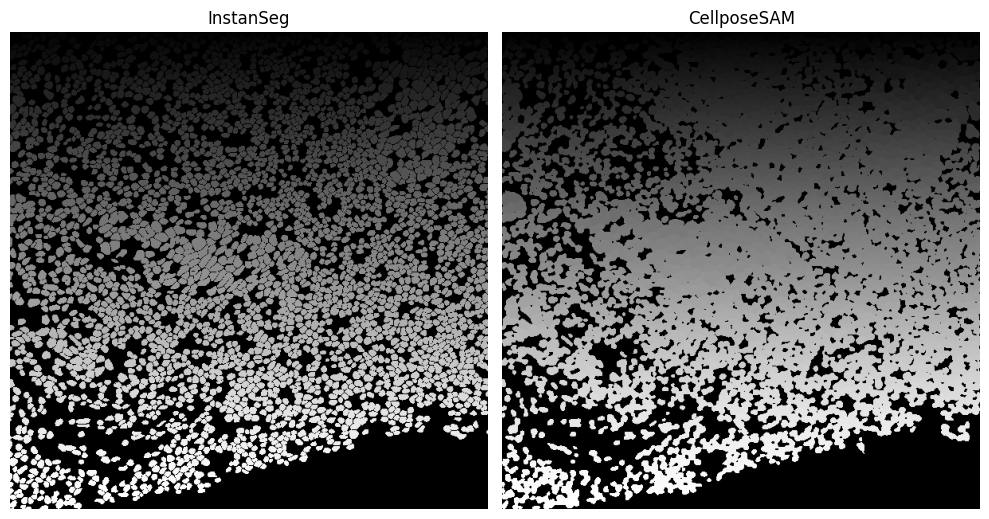

In [9]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
im1 = axs[0].imshow(mask_instanseg, cmap='grey')
axs[0].axis("off")
axs[0].set_title("InstanSeg")
im2 = axs[1].imshow(mask_cellpose_sam, cmap='grey')
axs[1].axis("off")
axs[1].set_title("CellposeSAM")
plt.tight_layout()
plt.show()